In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   # must run before torch touches CUDA
!pip install -U transformers==4.56.2 "huggingface_hub<1.0" trl==1.6.0 peft==0.19.1 datasets accelerate matplotlib
!pip install --upgrade "torchao>=0.16.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 93.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.1/825.1 kB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 105.7 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 70.4 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda

In [2]:
from huggingface_hub import login
login()

In [3]:
from datasets import load_dataset

ds = load_dataset("trl-lib/ultrafeedback_binarized", split="train")
ds = ds.shuffle(seed=42).select(range(2000))   # small subset = fast weekend run
split = ds.train_test_split(test_size=0.1, seed=42)
train_ds, eval_ds = split["train"], split["test"]
print(train_ds[0])   # inspect the prompt/chosen/rejected structure

README.md:   0%|          | 0.00/643 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/131M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/2.14M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/62135 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

{'chosen': [{'content': "Summarize the following notes into a feedback about a candidate who was interviewed to our company. These notes are for a question I asked the candidate about Have Backbone, Disagree & Commit: Q: Tell me about a time when you strongly disagreed with your manager or peer on something you considered very important to the business. What was it and how did you handle it? Knowing what you know now, would you do anything differently? \n- 2020. We wanted to create a new product - a platform for the developers and data science. \n- They were two different approaches. Stand alone product. The other approach was to enhance the main product to enable... \nQ: What was the problem you were trying to solve? \n- we have our main product .. [tech details] \n- we want to develop algo that find bugs. \n- I thought it's not a good idea to build a new product and we can gain much more if we can build on top of the existing product. \n- One of my peers thought differently because h

In [4]:
import huggingface_hub, transformers
print(huggingface_hub.__version__, transformers.__version__)

0.36.2 4.56.2


In [5]:
from transformers import AutoTokenizer

model_id = "Qwen/Qwen2.5-0.5B-Instruct"
tok = AutoTokenizer.from_pretrained(model_id)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token
tok.padding_side = "left"

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [6]:
from trl.trainer.dpo_trainer import DPOTrainer
from trl.trainer.dpo_config import DPOConfig # Need to import DPOConfig here for re-definition
from peft import LoraConfig

peft_config = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05,
    target_modules="all-linear", task_type="CAUSAL_LM",
)

# Re-defining args with further reduced max_length and increased gradient_accumulation_steps
args = DPOConfig(
    output_dir="qwen2.5-0.5b-dpo",
    per_device_train_batch_size=1,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=16, # Keep at 32
    learning_rate=5e-5,
    num_train_epochs=1,
    max_steps=200,
    beta=0.1,
    max_length=512, # Further reduced from 256 to 128 to save more memory
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    fp16=True, bf16=False,
    report_to="none",
    gradient_checkpointing=True,
)

trainer = DPOTrainer(
    model=model_id,
    args=args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    processing_class=tok,
    peft_config=peft_config,
)
trainer.train()

2026-06-18 00:51:05.343653: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781743865.603051      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781743865.672541      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781743866.288001      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781743866.288032      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781743866.288035      58 computation_placer.cc:177] computation placer alr

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Extracting prompt from train dataset:   0%|          | 0/1800 [00:00<?, ? examples/s]

...

Extracting prompt from eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Logits/chosen,Logits/rejected,Mean Token Accuracy,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/chosen,Logps/rejected
50,0.616900,0.660098,1.337892,568148.000000,-2.032695,-1.967875,0.664446,-0.490492,-0.864073,0.525000,0.373581,-271.020869,-286.276384
100,0.640500,0.625413,1.318287,1135159.000000,-2.106301,-2.042750,0.663278,-0.425040,-0.825476,0.575000,0.400436,-270.366349,-285.890412
150,0.270500,0.618829,1.286721,1711955.000000,-2.199721,-2.141917,0.654305,-0.571764,-1.019097,0.600000,0.447333,-271.833586,-287.826619
200,0.241600,0.620012,1.268445,2275300.000000,-2.274891,-2.223773,0.653560,-0.738727,-1.266181,0.610000,0.527454,-273.503214,-290.297457


TrainOutput(global_step=200, training_loss=0.4824612259864807, metrics={'train_runtime': 2048.1818, 'train_samples_per_second': 1.562, 'train_steps_per_second': 0.098, 'total_flos': 5598216306408960.0, 'train_loss': 0.4824612259864807, 'epoch': 1.7733333333333334})

Ploting the curves (evidence)

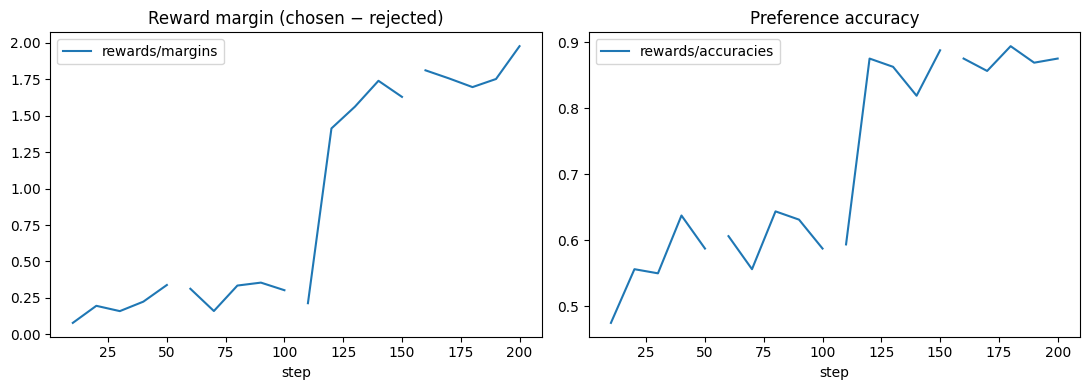

In [7]:
import pandas as pd, matplotlib.pyplot as plt

hist = pd.DataFrame(trainer.state.log_history)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
hist.plot(x="step", y="rewards/margins", ax=ax[0], title="Reward margin (chosen − rejected)")
hist.plot(x="step", y="rewards/accuracies", ax=ax[1], title="Preference accuracy")
plt.tight_layout(); plt.savefig("training_curves.png", dpi=120)

Before/after generations (the human-readable proof)

In [8]:
import torch
from transformers import AutoModelForCausalLM

def generate(model, prompt, n=200):
    msgs = [{"role": "user", "content": prompt}]
    ids = tok.apply_chat_template(msgs, add_generation_prompt=True, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(ids, max_new_tokens=n, do_sample=False)
    return tok.decode(out[0][ids.shape[1]:], skip_special_tokens=True)

base = AutoModelForCausalLM.from_pretrained(model_id, dtype=torch.float16).to("cuda")
tuned = trainer.model  # the LoRA-tuned model

for p in ["Explain why the sky is blue to a 5-year-old.",
          "Give me three tips for a first job interview."]:
    print("PROMPT:", p)
    print("  BASE :", generate(base, p)[:300])
    print("  DPO  :", generate(tuned, p)[:300], "\n")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


PROMPT: Explain why the sky is blue to a 5-year-old.
  BASE : To a 5-year-old, the sky being blue can be explained in several simple ways:

1. **Color Mixing**: Imagine you have two colors of paint - red and blue. When you mix these paints together, they create a new color called "blue." The sky is like this mixed-up paint.

2. **Light Reflections**: Just as w
  DPO  : To a 5-year-old, the sky being blue can be explained in simple terms:

The sky appears blue because it reflects sunlight. Just like how your eyes see colors when you look at things, our eyes also see light and color through the atmosphere. When sunlight hits the Earth's surface, it bounces off diffe 

PROMPT: Give me three tips for a first job interview.
  BASE : Certainly! Here are three tips to help you prepare for your first job interview:

1. **Research the Company**: Before your interview day, research the company thoroughly. Look at their website, read their mission statement and recent news articles, and review an